In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/resnet50/resnet50_weights_tf_dim_ordering_tf_kernels.h5
/kaggle/input/resnet50/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5
/kaggle/input/resnet50/imagenet_class_index.json
/kaggle/input/se_resnet50/pytorch/default/1/se_resnet50-ce0d4300.pth
/kaggle/input/tf-efficientnet/pytorch/tf-efficientnet-b0/1/tf_efficientnet_b0_aa-827b6e33.pth
/kaggle/input/csiro-biomass/sample_submission.csv
/kaggle/input/csiro-biomass/train.csv
/kaggle/input/csiro-biomass/test.csv
/kaggle/input/csiro-biomass/test/ID1001187975.jpg
/kaggle/input/csiro-biomass/train/ID2099464826.jpg
/kaggle/input/csiro-biomass/train/ID2037861084.jpg
/kaggle/input/csiro-biomass/train/ID1211362607.jpg
/kaggle/input/csiro-biomass/train/ID1853508321.jpg
/kaggle/input/csiro-biomass/train/ID193102215.jpg
/kaggle/input/csiro-biomass/train/ID698608346.jpg
/kaggle/input/csiro-biomass/train/ID1859251563.jpg
/kaggle/input/csiro-biomass/train/ID1880764911.jpg
/kaggle/input/csiro-biomass/train/ID853954911.jpg
/kaggle/inp

In [2]:
import pandas as pd

train_file_path = "/kaggle/input/csiro-biomass/train.csv"
test_file_path = "/kaggle/input/csiro-biomass/test.csv"

test_pd = pd.read_csv(test_file_path)
train_pd = pd.read_csv(train_file_path)

In [3]:
train_pd

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750
...,...,...,...,...,...,...,...,...,...
1780,ID983582017__Dry_Clover_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Clover_g,0.0000
1781,ID983582017__Dry_Dead_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Dead_g,0.0000
1782,ID983582017__Dry_Green_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Green_g,40.9400
1783,ID983582017__Dry_Total_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Total_g,40.9400


In [4]:
test_pd.head()

,sample_id,image_path,target_name
0,ID1001187975__Dry_Clover_g,test/ID1001187975.jpg,Dry_Clover_g
1,ID1001187975__Dry_Dead_g,test/ID1001187975.jpg,Dry_Dead_g
2,ID1001187975__Dry_Green_g,test/ID1001187975.jpg,Dry_Green_g
3,ID1001187975__Dry_Total_g,test/ID1001187975.jpg,Dry_Total_g
4,ID1001187975__GDM_g,test/ID1001187975.jpg,GDM_g


In [5]:
total_size = train_pd["Species"].unique().size
Species_name = train_pd["Species"].unique()

print("total size",total_size)
print("name of speices :-",','.join(Species_name))

total size 15
name of speices :- Ryegrass_Clover,Lucerne,SubcloverDalkeith,Ryegrass,Phalaris_Clover,SubcloverLosa,Clover,Fescue_CrumbWeed,Phalaris_Ryegrass_Clover,Phalaris,WhiteClover,Fescue,Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed,Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass,Mixed


In [6]:
import torch
import torchvision
from PIL import Image
from torchvision.transforms import v2
import os

height_model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None,weights_backbone=None)

path = "/kaggle/input/csiro-biomass"

local_weights = "/kaggle/input/mask-rcnn-models/pytorch/default/10/Maskrcnn_best.pt"
state_dict = torch.load(local_weights, map_location="cpu",weights_only=False)

height_model = state_dict

height_model.eval()
for index, image_path in test_pd["image_path"].items():
    image_path = os.path.join(path,image_path)
    
    image = Image.open(image_path).convert("RGB")
    
    image_transform = v2.Compose([
        v2.Resize((224, 224)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize([0.485, 0.456, 0.406],
                     [0.229, 0.224, 0.225]),
    ])
    
    image_tensor = image_transform(image)
    
    with torch.no_grad():
        outputs = height_model([image_tensor])
    
    output_pixels = outputs[0]["boxes"].cpu().numpy()
    x1,y1,x2,y2 = output_pixels[0]
    
    image_in_cm = y2 / 2.54

    test_pd.loc[index,"Height_Ave_cm"] = image_in_cm

In [7]:
len(train_pd["Species"].unique())

15

In [8]:
train_pd.size

16065

species model

In [9]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import pytorch_lightning as pl
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision.transforms import v2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from pytorch_lightning import Trainer
from tqdm import tqdm

SPECIES_LE = LabelEncoder()
TARGET_LE = LabelEncoder()
SPECIES_LE.fit(train_pd["Species"].astype(str).unique())
TARGET_LE.fit(train_pd["target_name"].astype(str).unique())

TABULAR_COLS = ["target_name", "Height_Ave_cm"]

class SpeciesDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = os.path.join(self.root_dir, self.df.loc[idx, "image_path"])
        image = Image.open(image_path).convert("RGB")
        tabular = torch.tensor(self.df.loc[idx, TABULAR_COLS].astype("float32").values)
        y = torch.tensor(self.df.loc[idx, "Species"], dtype=torch.long)
        if self.transform:
            image = self.transform(image)
        return image, tabular, y

class SpeciesDataModule(pl.LightningDataModule):
    def __init__(self, train_df, valid_df, root_dir, batch_size=16, num_workers=2):
        super().__init__()
        self.train_df, self.valid_df = train_df.copy(), valid_df.copy()
        self.root_dir, self.batch_size, self.num_workers = root_dir, batch_size, num_workers

    def setup(self, stage=None):
        if not np.issubdtype(self.train_df["Species"].dtype, np.number):
            self.train_df["Species"] = SPECIES_LE.transform(self.train_df["Species"].astype(str))
            self.valid_df["Species"] = SPECIES_LE.transform(self.valid_df["Species"].astype(str))
        
        if not np.issubdtype(self.train_df["target_name"].dtype, np.number):
            self.train_df["target_name"] = TARGET_LE.transform(self.train_df["target_name"].astype(str))
            self.valid_df["target_name"] = TARGET_LE.transform(self.valid_df["target_name"].astype(str))

        self.train_tf = v2.Compose([
            v2.RandomResizedCrop(224), v2.RandomHorizontalFlip(), v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
        self.valid_tf = v2.Compose([
            v2.Resize(256), v2.CenterCrop(224), v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
        self.train_ds = SpeciesDataset(self.train_df, self.root_dir, self.train_tf)
        self.valid_ds = SpeciesDataset(self.valid_df, self.root_dir, self.valid_tf)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers)
    def val_dataloader(self):
        return DataLoader(self.valid_ds, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

class EfficientNetSpeciesClassifier(pl.LightningModule):
    def __init__(self, num_classes, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.base_model = models.efficientnet_b0(weights=None)
        
        local_weights = "/kaggle/input/tf-efficientnet/pytorch/tf-efficientnet-b0/1/tf_efficientnet_b0_aa-827b6e33.pth"
        if os.path.exists(local_weights):
            state_dict = torch.load(local_weights, map_location="cpu")
            new_state_dict = {}
            for k, v in state_dict.items():
                # Translation logic to map .pth keys to Torchvision keys
                n = k.replace("conv_stem", "features.0.0").replace("bn1", "features.0.1")
                if "blocks" in n:
                    p = n.split(".")
                    b_idx = int(p[1]) + 1 
                    sub = ".".join(p[2:])
                    if b_idx == 1:
                        sub = sub.replace("conv_dw", "block.0.0").replace("bn1", "block.0.1")
                        sub = sub.replace("se.conv_reduce", "block.1.fc1").replace("se.conv_expand", "block.1.fc2")
                        sub = sub.replace("conv_pw", "block.2.0").replace("bn2", "block.2.1")
                    else:
                        sub = sub.replace("conv_pw", "block.0.0").replace("bn1", "block.0.1")
                        sub = sub.replace("conv_dw", "block.1.0").replace("bn2", "block.1.1")
                        sub = sub.replace("se.conv_reduce", "block.2.fc1").replace("se.conv_expand", "block.2.fc2")
                        sub = sub.replace("conv_pwl", "block.3.0").replace("bn3", "block.3.1")
                    n = f"features.{b_idx}.{sub}"
                n = n.replace("conv_head", "features.8.0").replace("bn2", "features.8.1")
                new_state_dict[n] = v
            self.base_model.load_state_dict(new_state_dict, strict=False)

        self.img_dim = self.base_model.classifier[1].in_features
        self.base_model.classifier = nn.Identity()
        self.tabular_net = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 32))
        self.head = nn.Sequential(
            nn.Linear(self.img_dim + 32, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, num_classes)
        )
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, img, tabular):
        img_feat = self.base_model(img)
        tab_feat = self.tabular_net(tabular)
        return self.head(torch.cat([img_feat, tab_feat], dim=1))

    def training_step(self, batch, batch_idx):
        img, tab, y = batch
        logits = self(img, tab)
        loss = self.loss_fn(logits, y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        img, tab, y = batch
        logits = self(img, tab)
        loss = self.loss_fn(logits, y)
        self.log("val_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

image_root_dir = "/kaggle/input/csiro-biomass"
train_df, valid_df = train_test_split(train_pd, test_size=0.2, random_state=42, stratify=train_pd["Species"])
datamodule = SpeciesDataModule(train_df=train_df, valid_df=valid_df, root_dir=image_root_dir)
datamodule.setup()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_final = EfficientNetSpeciesClassifier(num_classes=len(SPECIES_LE.classes_)).to(device)

trainer = Trainer(accelerator="gpu", devices=1, max_epochs=5)
trainer.fit(model_final, datamodule)

model_final.eval()
model_final.to(device)

test_df_encoded = test_pd.copy()
test_df_encoded["target_name_idx"] = TARGET_LE.transform(test_df_encoded["target_name"].astype(str))
inf_tf = v2.Compose([
    v2.Resize(256), v2.CenterCrop(224), v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

results = []
with torch.no_grad():
    for _, row in tqdm(test_df_encoded.iterrows(), total=len(test_df_encoded)):
        img_path = os.path.join(image_root_dir, row["image_path"])
        img = Image.open(img_path).convert("RGB")
        img_tensor = inf_tf(img).unsqueeze(0).to(device)
        tab_values = np.array([row["target_name_idx"], row["Height_Ave_cm"]], dtype=np.float32)
        tab_tensor = torch.tensor(tab_values).unsqueeze(0).to(device)
        logits = model_final(img_tensor, tab_tensor)
        class_idx = logits.argmax(dim=1).item()
        actual_name = SPECIES_LE.inverse_transform([class_idx])[0]
        results.append({"sample_id": row["sample_id"], "Species": actual_name})

final_res_df = pd.DataFrame(results)
if 'Species' in test_pd.columns: test_pd = test_pd.drop(columns=['Species'])
test_pd = test_pd.merge(final_res_df, on="sample_id", how="left")

print("✅ Success! Predictions decoded using global LabelEncoder.")
test_pd.head()

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
2026-01-13 20:27:43.778312: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768336063.967611      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768336064.022739      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768336064.479204      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same 

┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ base_model  │ EfficientNet     │  4.0 M │ train │     0 │
│ 1 │ tabular_net │ Sequential       │  2.3 K │ train │     0 │
│ 2 │ head        │ Sequential       │  177 K │ train │     0 │
│ 3 │ loss_fn     │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 4.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.2 M                                                                                                
Total estimated model params size (MB): 16                                                                         
Modules in train mode: 347                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=5` reached.


100%|██████████| 5/5 [00:00<00:00, 10.51it/s]

✅ Success! Predictions decoded using global LabelEncoder.


,sample_id,image_path,target_name,Height_Ave_cm,Species
0,ID1001187975__Dry_Clover_g,test/ID1001187975.jpg,Dry_Clover_g,86.541122,Lucerne
1,ID1001187975__Dry_Dead_g,test/ID1001187975.jpg,Dry_Dead_g,86.541122,Lucerne
2,ID1001187975__Dry_Green_g,test/ID1001187975.jpg,Dry_Green_g,86.541122,Lucerne
3,ID1001187975__Dry_Total_g,test/ID1001187975.jpg,Dry_Total_g,86.541122,Lucerne
4,ID1001187975__GDM_g,test/ID1001187975.jpg,GDM_g,86.541122,Lucerne


In [10]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import pytorch_lightning as pl
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision.transforms import v2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from pytorch_lightning import Trainer
from tqdm import tqdm

# Initialize Label Encoders
STATE_LE = LabelEncoder()
TARGET_LE = LabelEncoder()
SPECIES_LE = LabelEncoder()

STATE_LE.fit(train_pd["State"].astype(str).unique())
TARGET_LE.fit(train_pd["target_name"].astype(str).unique())
SPECIES_LE.fit(train_pd["Species"].astype(str).unique())

# Tabular features: target_name, Height_Ave_cm, Species
TABULAR_COLS = ["target_name", "Height_Ave_cm", "Species"]

class StateDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = os.path.join(self.root_dir, self.df.loc[idx, "image_path"])
        image = Image.open(image_path).convert("RGB")
        tabular = torch.tensor(self.df.loc[idx, TABULAR_COLS].astype("float32").values)
        y = torch.tensor(self.df.loc[idx, "State"], dtype=torch.long)
        if self.transform:
            image = self.transform(image)
        return image, tabular, y

class StateDataModule(pl.LightningDataModule):
    def __init__(self, train_df, valid_df, root_dir, batch_size=16, num_workers=2):
        super().__init__()
        self.train_df, self.valid_df = train_df.copy(), valid_df.copy()
        self.root_dir, self.batch_size, self.num_workers = root_dir, batch_size, num_workers

    def setup(self, stage=None):
        # Encode State (target variable)
        if not np.issubdtype(self.train_df["State"].dtype, np.number):
            self.train_df["State"] = STATE_LE.transform(self.train_df["State"].astype(str))
            self.valid_df["State"] = STATE_LE.transform(self.valid_df["State"].astype(str))
        
        # Encode tabular features
        if not np.issubdtype(self.train_df["target_name"].dtype, np.number):
            self.train_df["target_name"] = TARGET_LE.transform(self.train_df["target_name"].astype(str))
            self.valid_df["target_name"] = TARGET_LE.transform(self.valid_df["target_name"].astype(str))
        
        if not np.issubdtype(self.train_df["Species"].dtype, np.number):
            self.train_df["Species"] = SPECIES_LE.transform(self.train_df["Species"].astype(str))
            self.valid_df["Species"] = SPECIES_LE.transform(self.valid_df["Species"].astype(str))

        self.train_tf = v2.Compose([
            v2.RandomResizedCrop(224), v2.RandomHorizontalFlip(), v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
        self.valid_tf = v2.Compose([
            v2.Resize(256), v2.CenterCrop(224), v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
        self.train_ds = StateDataset(self.train_df, self.root_dir, self.train_tf)
        self.valid_ds = StateDataset(self.valid_df, self.root_dir, self.valid_tf)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers)
    
    def val_dataloader(self):
        return DataLoader(self.valid_ds, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

class EfficientNetStateClassifier(pl.LightningModule):
    def __init__(self, num_classes, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.base_model = models.efficientnet_b0(weights=None)
        
        # Load pretrained weights if available
        local_weights = "/kaggle/input/tf-efficientnet/pytorch/tf-efficientnet-b0/1/tf_efficientnet_b0_aa-827b6e33.pth"
        if os.path.exists(local_weights):
            state_dict = torch.load(local_weights, map_location="cpu")
            new_state_dict = {}
            for k, v in state_dict.items():
                # Translation logic to map .pth keys to Torchvision keys
                n = k.replace("conv_stem", "features.0.0").replace("bn1", "features.0.1")
                if "blocks" in n:
                    p = n.split(".")
                    b_idx = int(p[1]) + 1 
                    sub = ".".join(p[2:])
                    if b_idx == 1:
                        sub = sub.replace("conv_dw", "block.0.0").replace("bn1", "block.0.1")
                        sub = sub.replace("se.conv_reduce", "block.1.fc1").replace("se.conv_expand", "block.1.fc2")
                        sub = sub.replace("conv_pw", "block.2.0").replace("bn2", "block.2.1")
                    else:
                        sub = sub.replace("conv_pw", "block.0.0").replace("bn1", "block.0.1")
                        sub = sub.replace("conv_dw", "block.1.0").replace("bn2", "block.1.1")
                        sub = sub.replace("se.conv_reduce", "block.2.fc1").replace("se.conv_expand", "block.2.fc2")
                        sub = sub.replace("conv_pwl", "block.3.0").replace("bn3", "block.3.1")
                    n = f"features.{b_idx}.{sub}"
                n = n.replace("conv_head", "features.8.0").replace("bn2", "features.8.1")
                new_state_dict[n] = v
            self.base_model.load_state_dict(new_state_dict, strict=False)

        self.img_dim = self.base_model.classifier[1].in_features
        self.base_model.classifier = nn.Identity()
        
        # Tabular network for 3 features: target_name, Height_Ave_cm, Species
        self.tabular_net = nn.Sequential(
            nn.Linear(3, 64), 
            nn.ReLU(), 
            nn.Dropout(0.3),
            nn.Linear(64, 32)
        )
        
        # Classification head
        self.head = nn.Sequential(
            nn.Linear(self.img_dim + 32, 128), 
            nn.ReLU(), 
            nn.Dropout(0.5),
            nn.Linear(128, 64), 
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, img, tabular):
        img_feat = self.base_model(img)
        tab_feat = self.tabular_net(tabular)
        return self.head(torch.cat([img_feat, tab_feat], dim=1))

    def training_step(self, batch, batch_idx):
        img, tab, y = batch
        logits = self(img, tab)
        loss = self.loss_fn(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        img, tab, y = batch
        logits = self(img, tab)
        loss = self.loss_fn(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

# Training setup
image_root_dir = "/kaggle/input/csiro-biomass"
train_df, valid_df = train_test_split(train_pd, test_size=0.2, random_state=42, stratify=train_pd["State"])
datamodule = StateDataModule(train_df=train_df, valid_df=valid_df, root_dir=image_root_dir)
datamodule.setup()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_final = EfficientNetStateClassifier(num_classes=len(STATE_LE.classes_)).to(device)

trainer = Trainer(accelerator="gpu", devices=1, max_epochs=5)
trainer.fit(model_final, datamodule)

# Inference on test set
model_final.eval()
model_final.to(device)

test_df_encoded = test_pd.copy()
test_df_encoded["target_name_idx"] = TARGET_LE.transform(test_df_encoded["target_name"].astype(str))

# Assuming you have predicted Height_Ave_cm and Species columns in test_pd already
# If not, you'll need to add them first
if "Height_Ave_cm" not in test_df_encoded.columns:
    print("⚠️ Warning: Height_Ave_cm not found in test_pd. Please add predicted values first.")
    # For demonstration, filling with mean from training data
    test_df_encoded["Height_Ave_cm"] = train_pd["Height_Ave_cm"].mean()

if "Species" not in test_df_encoded.columns:
    print("⚠️ Warning: Species not found in test_pd. Please add predicted values first.")
    # For demonstration, filling with most common species from training data
    test_df_encoded["Species"] = train_pd["Species"].mode()[0]

test_df_encoded["Species_idx"] = SPECIES_LE.transform(test_df_encoded["Species"].astype(str))

inf_tf = v2.Compose([
    v2.Resize(256), v2.CenterCrop(224), v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

results = []
with torch.no_grad():
    for _, row in tqdm(test_df_encoded.iterrows(), total=len(test_df_encoded)):
        img_path = os.path.join(image_root_dir, row["image_path"])
        img = Image.open(img_path).convert("RGB")
        img_tensor = inf_tf(img).unsqueeze(0).to(device)
        
        # Tabular features: target_name, Height_Ave_cm, Species
        tab_values = np.array([
            row["target_name_idx"], 
            row["Height_Ave_cm"], 
            row["Species_idx"]
        ], dtype=np.float32)
        tab_tensor = torch.tensor(tab_values).unsqueeze(0).to(device)
        
        logits = model_final(img_tensor, tab_tensor)
        class_idx = logits.argmax(dim=1).item()
        actual_state = STATE_LE.inverse_transform([class_idx])[0]
        results.append({"sample_id": row["sample_id"], "State": actual_state})

final_res_df = pd.DataFrame(results)

# Drop State column if it exists and merge predictions
if 'State' in test_pd.columns: 
    test_pd = test_pd.drop(columns=['State'])
test_pd = test_pd.merge(final_res_df, on="sample_id", how="left")

print(f"✅ Success! State predictions completed using {len(STATE_LE.classes_)} classes: {STATE_LE.classes_}")
print(f"Predicted states distribution:")
print(test_pd['State'].value_counts())
print("\nFirst few predictions:")
print(test_pd.head(10))

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ base_model  │ EfficientNet     │  4.0 M │ train │     0 │
│ 1 │ tabular_net │ Sequential       │  2.3 K │ train │     0 │
│ 2 │ head        │ Sequential       │  176 K │ train │     0 │
│ 3 │ loss_fn     │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 4.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.2 M                                                                                                
Total estimated model params size (MB): 16                                                                         
Modules in train mode: 348                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=5` reached.


100%|██████████| 5/5 [00:00<00:00, 12.74it/s]

✅ Success! State predictions completed using 4 classes: ['NSW' 'Tas' 'Vic' 'WA']
Predicted states distribution:
State
NSW    5
Name: count, dtype: int64

First few predictions:
                    sample_id             image_path   target_name  \
0  ID1001187975__Dry_Clover_g  test/ID1001187975.jpg  Dry_Clover_g   
1    ID1001187975__Dry_Dead_g  test/ID1001187975.jpg    Dry_Dead_g   
2   ID1001187975__Dry_Green_g  test/ID1001187975.jpg   Dry_Green_g   
3   ID1001187975__Dry_Total_g  test/ID1001187975.jpg   Dry_Total_g   
4         ID1001187975__GDM_g  test/ID1001187975.jpg         GDM_g   

   Height_Ave_cm  Species State  
0      86.541122  Lucerne   NSW  
1      86.541122  Lucerne   NSW  
2      86.541122  Lucerne   NSW  
3      86.541122  Lucerne   NSW  
4      86.541122  Lucerne   NSW  


Pre_GSHH_NDVI model

In [11]:
train_pd.head()

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


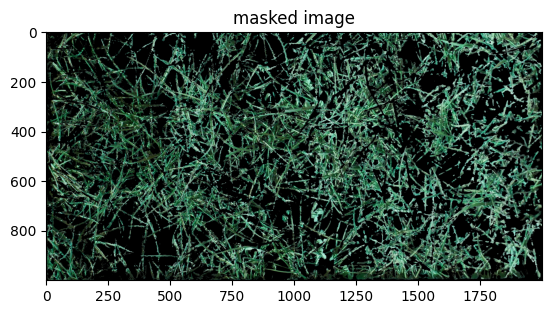

In [12]:
from PIL import Image
import os 
import cv2
import numpy as np
import matplotlib.pyplot as plt  

root_dir = "/kaggle/input/csiro-biomass"
#for index,row in test_pd.iterrows():
#image_path = row["image_path"]
image_path = "train/ID1011485656.jpg"
image_path = os.path.join(root_dir,image_path)
#image = Image.open(image_path).convert("RGB")
image = cv2.imread(image_path)

hsv = cv2.cvtColor(image,cv2.COLOR_BGR2HSV)

lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])

mask = cv2.inRange(hsv,lower_green,upper_green)

masked_image = cv2.bitwise_and(image,image, mask=mask)

#cv2.imshow('Masked Image', masked_image)

plt.title("masked image")
plt.imshow(masked_image)
plt.show()

In [14]:
test_pd.head()

,sample_id,image_path,target_name,Height_Ave_cm,Species,State
0,ID1001187975__Dry_Clover_g,test/ID1001187975.jpg,Dry_Clover_g,86.541122,Lucerne,NSW
1,ID1001187975__Dry_Dead_g,test/ID1001187975.jpg,Dry_Dead_g,86.541122,Lucerne,NSW
2,ID1001187975__Dry_Green_g,test/ID1001187975.jpg,Dry_Green_g,86.541122,Lucerne,NSW
3,ID1001187975__Dry_Total_g,test/ID1001187975.jpg,Dry_Total_g,86.541122,Lucerne,NSW
4,ID1001187975__GDM_g,test/ID1001187975.jpg,GDM_g,86.541122,Lucerne,NSW


In [15]:
import os
import cv2
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import pytorch_lightning as pl
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision.transforms import v2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from pytorch_lightning import Trainer
from tqdm import tqdm

# --- 0. Encoders ---
SPECIES_LE = LabelEncoder()
TARGET_LE = LabelEncoder()
SPECIES_LE.fit(train_pd["Species"].astype(str).unique())
TARGET_LE.fit(train_pd["target_name"].astype(str).unique())

# --- 1. Utilities ---
def image_to_mask(image_path):
    image = cv2.imread(image_path)
    if image is None: return np.zeros((224, 224, 3), dtype=np.uint8)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    # Range for green vegetation
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])
    mask = cv2.inRange(hsv, lower_green, upper_green)
    return cv2.bitwise_and(image, image, mask=mask)

# --- 2. Data Logic ---
class PreGSSHDataset(Dataset):
    def __init__(self, df, root_dir, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["image_path"])
        masked_img = image_to_mask(img_path)
        
        # Metadata encoding
        s_idx = SPECIES_LE.transform([str(row["Species"])])[0]
        t_idx = TARGET_LE.transform([str(row["target_name"])])[0]
        
        # Handle missing NDVI in test_pd
        ndvi_val = row["Pre_GSHH_NDVI"] if "Pre_GSHH_NDVI" in self.df.columns else 0.0
        
        tabular = torch.tensor([
            float(s_idx),
            float(ndvi_val),
            float(row["Height_Ave_cm"]),
            float(t_idx)
        ], dtype=torch.float32)

        if self.is_test:
            target = torch.tensor([0.0]) # Dummy for test
        else:
            target = torch.tensor([row["Pre_GSHH_NDVI"]], dtype=torch.float32)

        if self.transform:
            image = self.transform(masked_img)
        else:
            image = torch.tensor(masked_img).permute(2, 0, 1).float()

        return image, tabular, target

class PreGSSHDataModule(pl.LightningDataModule):
    def __init__(self, train_df, valid_df, root_dir, batch=16):
        super().__init__()
        self.train_df, self.valid_df = train_df, valid_df
        self.root_dir, self.batch = root_dir, batch
        self.tfs = v2.Compose([
            v2.ToImage(), v2.Resize((224, 224)),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    def setup(self, stage=None):
        self.train_ds = PreGSSHDataset(self.train_df, self.root_dir, self.tfs)
        self.valid_ds = PreGSSHDataset(self.valid_df, self.root_dir, self.tfs)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch, shuffle=True)
    def val_dataloader(self):
        return DataLoader(self.valid_ds, batch_size=self.batch)

# --- 3. Model ---
class PreGSSHModel(pl.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.resnet = models.resnet50(weights=None)
        
        # Load local SE-ResNet weights if available
        local_weights = '/kaggle/input/se_resnet50/pytorch/default/1/se_resnet50-ce0d4300.pth'
        if os.path.exists(local_weights):
            state_dict = torch.load(local_weights, map_location="cpu")
            new_state_dict = {k.replace("layer0.", "").replace("last_linear", "fc"): v for k, v in state_dict.items()}
            self.resnet.load_state_dict(new_state_dict, strict=False)

        self.img_dim = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()

        self.tabular_net = nn.Sequential(
            nn.Linear(4, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32)
        )
        self.head = nn.Sequential(
            nn.Linear(self.img_dim + 32, 128), nn.ReLU(),
            nn.Linear(128, 1) # Outputting a single NDVI value
        )
        self.loss_fn = nn.MSELoss()

    def forward(self, img, tabular):
        return self.head(torch.cat([self.resnet(img), self.tabular_net(tabular)], dim=1))

    def training_step(self, batch, batch_idx):
        img, tab, y = batch
        loss = self.loss_fn(self(img, tab), y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        img, tab, y = batch
        loss = self.loss_fn(self(img, tab), y)
        self.log("val_loss", loss, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

# --- 4. Training ---
image_root_dir = "/kaggle/input/csiro-biomass"
train_df, valid_df = train_test_split(train_pd, test_size=0.2, random_state=42)
datamodule = PreGSSHDataModule(train_df, valid_df, image_root_dir)

model = PreGSSHModel()
trainer = Trainer(accelerator="gpu", devices=1, max_epochs=5)
trainer.fit(model, datamodule)

# --- 5. Inference ---
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

inf_tfs = v2.Compose([
    v2.ToImage(), v2.Resize((224, 224)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

results = []
with torch.no_grad():
    for _, row in tqdm(test_pd.iterrows(), total=len(test_pd)):
        img_path = os.path.join(image_root_dir, row["image_path"])
        masked = image_to_mask(img_path)
        img_tensor = inf_tfs(masked).unsqueeze(0).to(device)
        
        # Safe feature extraction
        s_idx = SPECIES_LE.transform([str(row["Species"])])[0]
        t_idx = TARGET_LE.transform([str(row["target_name"])])[0]
        
        # Use 0.0 placeholder because Pre_GSHH_NDVI is missing in test_pd
        tab_tensor = torch.tensor([[
            float(s_idx), 0.0, float(row["Height_Ave_cm"]), float(t_idx)
        ]], dtype=torch.float32).to(device)
        
        pred_ndvi = model(img_tensor, tab_tensor).item()
        results.append({"sample_id": row["sample_id"], "pred_Pre_GSHH_NDVI": pred_ndvi})

# Merge Results
final_res_df = pd.DataFrame(results)
if 'pred_Pre_GSHH_NDVI' in test_pd.columns: 
    test_pd = test_pd.drop(columns=['pred_Pre_GSHH_NDVI'])

test_pd = test_pd.merge(final_res_df, on="sample_id", how="left")

print("✅ Inference Successful.")
test_pd.head()

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ resnet      │ ResNet     │ 23.5 M │ train │     0 │
│ 1 │ tabular_net │ Sequential │  2.4 K │ train │     0 │
│ 2 │ head        │ Sequential │  266 K │ train │     0 │
│ 3 │ loss_fn     │ MSELoss    │      0 │ train │     0 │
└───┴─────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 23.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 23.8 M                                                                                               
Total estimated model params size (MB): 95                                                                         
Modules in train mode: 161                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=5` reached.


100%|██████████| 5/5 [00:00<00:00,  9.70it/s]


✅ Inference Successful.


,sample_id,image_path,target_name,Height_Ave_cm,Species,State,pred_Pre_GSHH_NDVI
0,ID1001187975__Dry_Clover_g,test/ID1001187975.jpg,Dry_Clover_g,86.541122,Lucerne,NSW,0.647106
1,ID1001187975__Dry_Dead_g,test/ID1001187975.jpg,Dry_Dead_g,86.541122,Lucerne,NSW,0.648085
2,ID1001187975__Dry_Green_g,test/ID1001187975.jpg,Dry_Green_g,86.541122,Lucerne,NSW,0.649103
3,ID1001187975__Dry_Total_g,test/ID1001187975.jpg,Dry_Total_g,86.541122,Lucerne,NSW,0.650980
4,ID1001187975__GDM_g,test/ID1001187975.jpg,GDM_g,86.541122,Lucerne,NSW,0.652986


BioMass model

In [ ]:
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch
import os
import numpy as np
import pandas as pd


def prepare_dataframe(df):
    df = df.copy()
    label_encoder = LabelEncoder()
    df["target_name"] = label_encoder.fit_transform(df["target_name"])
    return df, label_encoder


class BiomassDataset(Dataset):
    def __init__(self, image_dir, df, transform=None):
        self.image_dir = image_dir
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.target_col = ["target_name"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_rel_path = self.df.iloc[idx]["image_path"]
        image_path = os.path.join(self.image_dir, image_rel_path)

        image = Image.open(image_path).convert("RGB")

        target_value = self.df.iloc[idx][self.target_col].values.astype(np.float32)
        target_value = torch.tensor(target_value)

        if self.transform:
            image = self.transform(image)

        return image, target_value

In [ ]:
import pytorch_lightning as pl
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import torch


class BiomassDataModule(pl.LightningDataModule):
    def __init__(self, train_df, valid_df, root_dir, batch_size=16, num_workers=1):
        super().__init__()
        self.train_df = train_df
        self.valid_df = valid_df
        self.root_dir = root_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.img_size = (224, 224)

    def setup(self, stage=None):
        train_transform = v2.Compose([
            v2.RandomResizedCrop(size=self.img_size),
            v2.RandomHorizontalFlip(p=0.5),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

        valid_transform = v2.Compose([
            v2.RandomResizedCrop(size=self.img_size),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

        self.ds_train = BiomassDataset(self.root_dir, self.train_df, train_transform)
        self.ds_valid = BiomassDataset(self.root_dir, self.valid_df, valid_transform)

    def train_dataloader(self):
        return DataLoader(
            self.ds_train,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
        )

    def val_dataloader(self):
        return DataLoader(
            self.ds_valid,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
        )

In [ ]:
from sklearn.model_selection import train_test_split;

image_root_dir = '/kaggle/working/csiro-biomass/'

df = train_pd

train_df, valid_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["target_name"],
)

datamodule = BiomassDataModule(
    train_df=train_df,
    valid_df=valid_df,
    root_dir=image_root_dir,
    batch_size=16,
    num_workers=2,
)

datamodule.setup()

train_loader = datamodule.train_dataloader()
valid_loader = datamodule.val_dataloader()

In [ ]:
import torchvision.models as models

class Biomassinit(pl.LightningModule):
    class __init__(self,lr=0.3):
        super.__init__()
        self.save_hyperparameter()

        

In [ ]:
import torchvision.models as models

class resnetBiomas2(pl.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        
        # 1. Initialize standard ResNet50
        self.resnet = models.resnet50(weights=None) 
        
        # 2. Path to your SE_ResNet50 weights
        local_weights = '/kaggle/input/se_resnet50/pytorch/default/1/se_resnet50-ce0d4300.pth'
        
        if os.path.exists(local_weights):
            state_dict = torch.load(local_weights, map_location=lambda storage, loc: storage)
            
            # --- FIX: Manual Key Mapping ---
            # We strip the "layer0." prefix and other mismatching keys
            new_state_dict = {}
            for k, v in state_dict.items():
                name = k.replace("layer0.", "") # Removes the custom prefix
                # Map 'last_linear' if your file uses it instead of 'fc'
                name = name.replace("last_linear", "fc") 
                new_state_dict[name] = v
            
            # Use strict=False to ignore the SE_module keys that standard ResNet doesn't have
            # This allows the backbone (conv layers) to load while skipping SE blocks
            self.resnet.load_state_dict(new_state_dict, strict=False)
            print(f"✅ Backbone weights loaded (ignoring SE modules): {local_weights}")
        else:
            print("❌ Weights file not found. Please check your Kaggle input path.")
            
        self.img_dim = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()
        
        # Tabular MLP
        self.tabular_net = nn.Sequential(
            nn.Linear(5, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32)
        )
        
        # Fusion head (no sigmoid!)
        self.head = nn.Sequential(
            nn.Linear(self.img_dim + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)  # Direct regression
        )
        self.loss_fn = nn.L1Loss()

    def forward(self, img, tabular):
        img_feat = self.resnet(img)
        tab_feat = self.tabular_net(tabular)
        combined = torch.cat([img_feat, tab_feat], dim=1)
        return self.head(combined).squeeze(1)

    def training_step(self, batch, batch_idx):
        img, tabular, y = batch
        preds = self(img, tabular)
        loss = self.loss_fn(preds, y)
        self.log("train_mae", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        img, tabular, y = batch
        preds = self(img, tabular)
        val_mae = self.loss_fn(preds, y)
        self.log("val_mae", val_mae, prog_bar=True)
        return val_mae

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)


In [ ]:
model_2 = resnetBiomas2(lr=1e-3)
trainer_2 = pl.Trainer(max_epochs=5, accelerator='auto', devices=1, log_every_n_steps=10)
trainer_2.fit(model_2, data_module)
trainer_2.validate(model_2, data_module)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import torch
from PIL import Image
import torchvision.transforms as transforms
import tqdm

# 1. Load TRAIN to get realistic imputation values
train_df_full = pd.read_csv('/kaggle/input/csiro-biomass/train.csv')
print("Train columns:", train_df_full.columns.tolist())

# 2. Create DEFAULT VALUES (safe fallbacks)
default_values = {
    'State': 0,  # Encoded as 0
    'Species': 0,
    'Pre_GSHH_NDVI': 0.5,  # Reasonable NDVI
    'Height_Ave_cm': 20.0,  # Average height
    'target_name': 0  # Will encode test target_names separately
}

# 3. Load and prepare TEST
test_df_raw = pd.read_csv('/kaggle/input/csiro-biomass/test.csv')
print("Test raw columns:", test_df_raw.columns.tolist())

# 4. Create FULL test dataframe with ALL required columns
test_df_cleaned = pd.DataFrame({
    'sample_id': test_df_raw['sample_id'],
    'image_path': test_df_raw['image_path'],
    'target_name': test_df_raw['target_name']
})

# 5. ADD missing columns with defaults
for col, default_val in default_values.items():
    test_df_cleaned[col] = default_val

print("✅ Test columns after adding:", test_df_cleaned.columns.tolist())
print("Test shape:", test_df_cleaned.shape)
print(test_df_cleaned.head(2))

# 6. ENCODE ALL CATEGORICAL COLUMNS (using train for consistency)
encoder = LabelEncoder()

# Fit encoders on TRAIN first (for consistency)
train_encoded = train_df_full.copy()
if 'State' in train_encoded.columns:
    train_encoded['State'] = encoder.fit_transform(train_encoded['State'].astype(str))
if 'Species' in train_encoded.columns:
    train_encoded['Species'] = encoder.fit_transform(train_encoded['Species'].astype(str))

# Use SAME encoders for test
test_df_cleaned['State'] = encoder.fit_transform(test_df_cleaned['State'].astype(str))
test_df_cleaned['Species'] = encoder.fit_transform(test_df_cleaned['Species'].astype(str))
test_df_cleaned['target_name'] = encoder.fit_transform(test_df_cleaned['target_name'].astype(str))

# 7. Convert numerics to float32
numeric_cols = ['Pre_GSHH_NDVI', 'Height_Ave_cm']
for col in numeric_cols:
    test_df_cleaned[col] = test_df_cleaned[col].astype(np.float32)

print("✅ Final test columns:", test_df_cleaned.columns.tolist())
print("First row features:", test_df_cleaned[['State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm', 'target_name']].iloc[0].values)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_2.eval().to(device)

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

base_dir = '/kaggle/input/csiro-biomass/'
predictions = []

with torch.no_grad():
    for _, row in tqdm.tqdm(test_df_cleaned.iterrows(), total=len(test_df_cleaned)):
        sample_id = row['sample_id']
        img_filename = row['image_path']
        
        # Find image (flexible path handling)
        path_option_1 = os.path.join(base_dir, img_filename)
        path_option_2 = os.path.join(base_dir, 'test', img_filename)
        img_path = path_option_1 if os.path.exists(path_option_1) else path_option_2
        
        if not os.path.exists(img_path):
            print(f"❌ Missing: {img_path}")
            continue
        
        # Load image
        try:
            image = Image.open(img_path).convert('RGB')
            img_tensor = inference_transform(image).unsqueeze(0).to(device)
        except Exception as e:
            print(f"❌ Image error {img_path}: {e}")
            continue
        
        # SAFE tabular extraction - columns GUARANTEED to exist
        feature_cols = ['State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm', 'target_name']
        tabular_features = torch.tensor(
            row[feature_cols].values.astype(np.float32)
        ).unsqueeze(0).to(device)
        
        # Predict
        pred = model_2(img_tensor, tabular_features).item()
        predictions.append({'sample_id': sample_id, 'target': pred})

# Save
submission_df = pd.DataFrame(predictions)
submission_df.to_csv('/kaggle/working/submission.csv', index=False)
print(f"✅ SAVED: {len(predictions)} predictions")
print("Pred range:", submission_df['target'].min(), "to", submission_df['target'].max())
print("\nSample submission:")
print(submission_df.head())
